# Module A — 面板資料分析 (Panel Data Analysis)

本筆記本對應 `1-Panel_Data_Analysis.pptx`。示範 Pooled OLS、固定效果 (FE)、隨機效果 (RE) 與 Hausman 檢定，使用製造業合成面板資料。

**學習目標**
1. 理解面板資料的結構特性（個體維度 × 時間維度）
2. 比較 Pooled OLS、固定效果、隨機效果三種估計方法
3. 以 Hausman 檢定進行模型選擇
4. 透過殘差診斷圖與係數比較圖解讀結果


In [1]:
!pip install -q pandas numpy statsmodels linearmodels matplotlib seaborn scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 13.7 MB/s eta 0:00:00


## 1. 載入製造業面板資料

使用 `create_sample_manufacturing_datasets()` 產生合成的設備性能面板資料。
資料集包含 50 台機器、24 個月的觀測值，共 1200 筆記錄。


📊 對應投影片 → [第 12 頁](https://yjjchen-nkust.github.io/course-lab/workshop_data/1-Panel_Data_Analysis.pdf#page=12)

### 資料集：CNC 機台維護面板（合成）
50 部 CNC 機台 × 24 個月平衡面板（seed 42，共 1200 列）。**這是合成資料，植入了已知係數**，正是用來示範固定效果 (FE) 能否回收真實效果的教學設計。

| 欄位 | 意義 | 範圍／真實係數 |
|---|---|---|
| entity | 機台（個體） | Machine_01–50 |
| time | 月 | 1–24 |
| monthly_failures | 每月故障率（目標） | ≥0 |
| maintenance_events | 維護次數 | 真實係數 −0.3 |
| machine_age_years | 機台年資 | 真實係數 +0.2 |
| daily_operating_hours | 日均運轉時數 | 真實係數 +0.1 |

**本節分析目標**：控制機台固有差異 (entity_effect) 後，維護是否真能降低故障——FE 應回收近 −0.3 的維護係數。詳見 `DATA_Module_A.md`。


In [2]:
import base64
b64 = """
aW1wb3J0IG51bXB5IGFzIG5wCmltcG9ydCBwYW5kYXMgYXMgcGQKaW1wb3J0IHN0YXRzbW9kZWxz
LmFwaSBhcyBzbQppbXBvcnQgbWF0cGxvdGxpYi5weXBsb3QgYXMgcGx0CmZyb20gc2NpcHkgaW1w
b3J0IHN0YXRzCmZyb20gbGluZWFybW9kZWxzLnBhbmVsIGltcG9ydCBQb29sZWRPTFMsIFBhbmVs
T0xTLCBSYW5kb21FZmZlY3RzCgoKZGVmIGNyZWF0ZV9zYW1wbGVfbWFudWZhY3R1cmluZ19kYXRh
c2V0cygpOgogICAgcm5nID0gbnAucmFuZG9tLlJhbmRvbVN0YXRlKDQyKQogICAgTiwgVCA9IDUw
LCAyNAogICAgYmFkbmVzcyA9IHJuZy5ub3JtYWwoMC4wLCAxLjAsIE4pCiAgICBhbHBoYSA9IDYu
MCArIDIuMCAqIGJhZG5lc3MKICAgIG1haW50X2xhbWJkYSA9IG5wLmNsaXAoNC4wICsgMS41ICog
YmFkbmVzcywgMC41LCBOb25lKQogICAgYWdlMCA9IHJuZy51bmlmb3JtKDEuMCwgOS4wLCBOKQog
ICAgcm93cyA9IFtdCiAgICBmb3IgaSBpbiByYW5nZShOKToKICAgICAgICBmb3IgdCBpbiByYW5n
ZSgxLCBUICsgMSk6CiAgICAgICAgICAgIG1haW50ZW5hbmNlID0gcm5nLnBvaXNzb24obWFpbnRf
bGFtYmRhW2ldKQogICAgICAgICAgICBhZ2UgPSBhZ2UwW2ldICsgKHQgLSAxKSAvIDEyLjAKICAg
ICAgICAgICAgaG91cnMgPSBmbG9hdChucC5jbGlwKHJuZy5ub3JtYWwoMTIuMCwgMy4wKSwgNC4w
LCAyMC4wKSkKICAgICAgICAgICAgbm9pc2UgPSBybmcubm9ybWFsKDAuMCwgMS4wKQogICAgICAg
ICAgICBmYWlsdXJlcyA9IGFscGhhW2ldIC0gMC4zICogbWFpbnRlbmFuY2UgKyAwLjIgKiBhZ2Ug
KyAwLjEgKiBob3VycyArIG5vaXNlCiAgICAgICAgICAgIGZhaWx1cmVzID0gbWF4KGZhaWx1cmVz
LCAwLjApCiAgICAgICAgICAgIHJvd3MuYXBwZW5kKHsiZW50aXR5IjogIk1hY2hpbmVfJTAyZCIg
JSAoaSArIDEpLCAidGltZSI6IHQsCiAgICAgICAgICAgICAgICAgICAgICAgICAibW9udGhseV9m
YWlsdXJlcyI6IHJvdW5kKGZhaWx1cmVzLCAzKSwKICAgICAgICAgICAgICAgICAgICAgICAgICJt
YWludGVuYW5jZV9ldmVudHMiOiBpbnQobWFpbnRlbmFuY2UpLAogICAgICAgICAgICAgICAgICAg
ICAgICAgIm1hY2hpbmVfYWdlX3llYXJzIjogcm91bmQoYWdlLCAzKSwKICAgICAgICAgICAgICAg
ICAgICAgICAgICJkYWlseV9vcGVyYXRpbmdfaG91cnMiOiByb3VuZChob3VycywgMil9KQogICAg
cmV0dXJuIHsiZXF1aXBtZW50X3BlcmZvcm1hbmNlIjogcGQuRGF0YUZyYW1lKHJvd3MpfQoKCmNs
YXNzIE1vZGVsUmVzdWx0OgogICAgZGVmIF9faW5pdF9fKHNlbGYsIG5hbWUsIHJhdywgcGFyYW1z
LCBjb3YsIHJlc2lkcywgZml0dGVkLCByX3NxdWFyZWQpOgogICAgICAgIHNlbGYubmFtZSA9IG5h
bWUKICAgICAgICBzZWxmLnJhdyA9IHJhdwogICAgICAgIHNlbGYucGFyYW1zID0gcGFyYW1zCiAg
ICAgICAgc2VsZi5jb3YgPSBjb3YKICAgICAgICBzZWxmLnJlc2lkcyA9IHJlc2lkcwogICAgICAg
IHNlbGYuZml0dGVkID0gZml0dGVkCiAgICAgICAgc2VsZi5yX3NxdWFyZWQgPSBmbG9hdChyX3Nx
dWFyZWQpCgogICAgZGVmIF9fcmVwcl9fKHNlbGYpOgogICAgICAgIHJldHVybiAiPE1vZGVsUmVz
dWx0ICVzOiBSMj0lLjRmPiIgJSAoc2VsZi5uYW1lLCBzZWxmLnJfc3F1YXJlZCkKCgpjbGFzcyBI
YXVzbWFuUmVzdWx0OgogICAgZGVmIF9faW5pdF9fKHNlbGYsIHN0YXRpc3RpYywgcF92YWx1ZSwg
ZGYsIHJlamVjdF9udWxsLCBjb25jbHVzaW9uKToKICAgICAgICBzZWxmLnN0YXRpc3RpYyA9IGZs
b2F0KHN0YXRpc3RpYykKICAgICAgICBzZWxmLnBfdmFsdWUgPSBmbG9hdChwX3ZhbHVlKQogICAg
ICAgIHNlbGYuZGYgPSBpbnQoZGYpCiAgICAgICAgc2VsZi5yZWplY3RfbnVsbCA9IGJvb2wocmVq
ZWN0X251bGwpCiAgICAgICAgc2VsZi5jb25jbHVzaW9uID0gY29uY2x1c2lvbgoKICAgIGRlZiBf
X3JlcHJfXyhzZWxmKToKICAgICAgICByZXR1cm4gIjxIYXVzbWFuUmVzdWx0IGNoaTI9JS40Ziwg
cD0lLjRmLCByZWplY3RfSDA9JXM+IiAlICgKICAgICAgICAgICAgc2VsZi5zdGF0aXN0aWMsIHNl
bGYucF92YWx1ZSwgc2VsZi5yZWplY3RfbnVsbCkKCgpjbGFzcyBQYW5lbERhdGFBbmFseXplcjoK
ICAgIGRlZiBfX2luaXRfXyhzZWxmLCBkYXRhLCBlbnRpdHlfY29sLCB0aW1lX2NvbCwgZGVwZW5k
ZW50X3Zhcik6CiAgICAgICAgc2VsZi5kYXRhID0gZGF0YS5jb3B5KCkKICAgICAgICBzZWxmLmVu
dGl0eV9jb2wgPSBlbnRpdHlfY29sCiAgICAgICAgc2VsZi50aW1lX2NvbCA9IHRpbWVfY29sCiAg
ICAgICAgc2VsZi5kZXBlbmRlbnRfdmFyID0gZGVwZW5kZW50X3ZhcgogICAgICAgIHNlbGYuX3Bh
bmVsID0gc2VsZi5kYXRhLnNldF9pbmRleChbZW50aXR5X2NvbCwgdGltZV9jb2xdKQoKICAgIGRl
ZiBmaXRfcG9vbGVkX29scyhzZWxmLCBpdnMpOgogICAgICAgIHkgPSBzZWxmLl9wYW5lbFtzZWxm
LmRlcGVuZGVudF92YXJdCiAgICAgICAgWCA9IHNtLmFkZF9jb25zdGFudChzZWxmLl9wYW5lbFts
aXN0KGl2cyldKQogICAgICAgIHJlcyA9IFBvb2xlZE9MUyh5LCBYKS5maXQoKQogICAgICAgIHJl
dHVybiBNb2RlbFJlc3VsdCgiUG9vbGVkIE9MUyIsIHJlcywgcmVzLnBhcmFtcywgcmVzLmNvdiwK
ICAgICAgICAgICAgICAgICAgICAgICAgICAgcmVzLnJlc2lkcywgcmVzLmZpdHRlZF92YWx1ZXMu
aWxvY1s6LCAwXSwgcmVzLnJzcXVhcmVkKQoKICAgIGRlZiBmaXRfZml4ZWRfZWZmZWN0cyhzZWxm
LCBpdnMsIGFkZF9jb25zdGFudD1GYWxzZSk6CiAgICAgICAgeSA9IHNlbGYuX3BhbmVsW3NlbGYu
ZGVwZW5kZW50X3Zhcl0KICAgICAgICBYID0gc2VsZi5fcGFuZWxbbGlzdChpdnMpXQogICAgICAg
IGlmIGFkZF9jb25zdGFudDoKICAgICAgICAgICAgWCA9IHNtLmFkZF9jb25zdGFudChYKQogICAg
ICAgIHJlcyA9IFBhbmVsT0xTKHksIFgsIGVudGl0eV9lZmZlY3RzPVRydWUpLmZpdCgpCiAgICAg
ICAgcmV0dXJuIE1vZGVsUmVzdWx0KCJGaXhlZCBFZmZlY3RzIiwgcmVzLCByZXMucGFyYW1zLCBy
ZXMuY292LAogICAgICAgICAgICAgICAgICAgICAgICAgICByZXMucmVzaWRzLCByZXMuZml0dGVk
X3ZhbHVlcy5pbG9jWzosIDBdLCByZXMucnNxdWFyZWQpCgogICAgZGVmIGZpdF9yYW5kb21fZWZm
ZWN0cyhzZWxmLCBpdnMpOgogICAgICAgIHkgPSBzZWxmLl9wYW5lbFtzZWxmLmRlcGVuZGVudF92
YXJdCiAgICAgICAgWCA9IHNtLmFkZF9jb25zdGFudChzZWxmLl9wYW5lbFtsaXN0KGl2cyldKQog
ICAgICAgIHJlcyA9IFJhbmRvbUVmZmVjdHMoeSwgWCkuZml0KCkKICAgICAgICByZXR1cm4gTW9k
ZWxSZXN1bHQoIlJhbmRvbSBFZmZlY3RzIiwgcmVzLCByZXMucGFyYW1zLCByZXMuY292LAogICAg
ICAgICAgICAgICAgICAgICAgICAgIHJlcy5yZXNpZHMsIHJlcy5maXR0ZWRfdmFsdWVzLmlsb2Mr
WzosIDBdLCByZXMucnNxdWFyZWQpCgogICAgZGVmIGhhdXNtYW5fdGVzdChzZWxmLCBmZSwgcmUp
OgogICAgICAgIGl2cyA9IFt2IGZvciB2IGluIGZlLnBhcmFtcy5pbmRleCBpZiB2ICE9ICJjb25z
dCJdCiAgICAgICAgYXVnID0gc2VsZi5fcGFuZWwuY29weSgpCiAgICAgICAgbWVhbl9jb2xzID0g
W10KICAgICAgICBmb3IgdiBpbiBpdnM6CiAgICAgICAgICAgIG1jb2wgPSB2ICsgIl9fbWVhbiIK
ICAgICAgICAgICAgYXVnW21jb2xdID0gYXVnLmdyb3VwYnkobGV2ZWw9MClbdl0udHJhbnNmb3Jt
KCJtZWFuIikKICAgICAgICAgICAgbWVhbl9jb2xzLmFwcGVuZChtY29sKQogICAgICAgIHkgPSBh
dWdbc2VsZi5kZXBlbmRlbnRfdmFyXQogICAgICAgIFggPSBzbS5hZGRfY29uc3RhbnQoYXVnW2l2
cyArIG1lYW5fY29sc10pCiAgICAgICAgcmVzID0gUmFuZG9tRWZmZWN0cyh5LCBYKS5maXQoKQog
ICAgICAgIGcgPSByZXMucGFyYW1zW21lYW5fY29sc10udmFsdWVzCiAgICAgICAgViA9IHJlcy5j
b3YubG9jW21lYW5fY29scywgbWVhbl9jb2xzXS52YWx1ZXMKICAgICAgICBzdGF0aXN0aWMgPSBm
bG9hdChnIEAgbnAubGluYWxnLmludihWKSBAIGcpCiAgICAgICAgZGYgPSBsZW4obWVhbl9jb2xz
KQogICAgICAgIHBfdmFsdWUgPSBmbG9hdChzdGF0cy5jaGkyLnNmKHN0YXRpc3RpYywgZGYpKQog
ICAgICAgIHJlamVjdCA9IHBfdmFsdWUgPCAwLjA1CiAgICAgICAgaWYgcmVqZWN0OgogICAgICAg
ICAgICBjb25jbHVzaW9uID0gInAgPCAwLjA1LCByZWplY3QgSDA6IGluZGl2aWR1YWwgZWZmZWN0
cyBjb3JyZWxhdGVkIHdpdGggcmVncmVzc29ycyAtPiB1c2UgRml4ZWQgRWZmZWN0cyAoRkUpLiIK
ICAgICAgICBlbHNlOgogICAgICAgICAgICBjb25jbHVzaW9uID0gInAgPj0gMC4wNSwgZmFpbCB0
byByZWplY3QgSDA6IFJhbmRvbSBFZmZlY3RzIChSRSkgaXMgYWNjZXB0YWJsZS4iCiAgICAgICAg
cmV0dXJuIEhhdXNtYW5SZXN1bHQoc3RhdGlzdGljLCBwX3ZhbHVlLCBkZiwgcmVqZWN0LCBjb25j
bHVzaW9uKQoKICAgIGRlZiBwbG90X3Jlc2lkdWFsc192c19maXR0ZWQoc2VsZiwgcmVzdWx0KToK
ICAgICAgICBmaXR0ZWQgPSBucC5hc2FycmF5KHJlc3VsdC5maXR0ZWQpLnJhdmVsKCkKICAgICAg
ICByZXNpZCA9IG5wLmFzYXJyYXkocmVzdWx0LnJlc2lkcykucmF2ZWwoKQogICAgICAgIGZpZywg
YXggPSBwbHQuc3VicGxvdHMoZmlnc2l6ZT0oNywgNSkpCiAgICAgICAgYXguc2NhdHRlcihmaXR0
ZWQsIHJlc2lkLCBhbHBoYT0wLjUsIGVkZ2Vjb2xvcj0ibm9uZSIpCiAgICAgICAgYXguYXhobGlu
ZSgwLCBjb2xvcj0icmVkIiwgbHc9MS4wLCBscz0iLS0iKQogICAgICAgIGF4LnNldF94bGFiZWwo
IkZpdHRlZCB2YWx1ZXMiKQogICAgICAgIGF4LnNldF95bGFiZWwoIlJlc2lkdWFscyIpCiAgICAg
ICAgYXguc2V0X3RpdGxlKCJSZXNpZHVhbHMgdnMgRml0dGVkIC0gIiArIHJlc3VsdC5uYW1lKQog
ICAgICAgIGF4LmdyaWQoVHJ1ZSwgYWxwaGE9MC4zKQogICAgICAgIHBsdC50aWdodF9sYXlvdXQo
KQogICAgICAgIHBsdC5zaG93KCkKCiAgICBkZWYgcGxvdF9jb2VmZmljaWVudF9jb21wYXJpc29u
KHNlbGYsIGZlLCByZSk6CiAgICAgICAgaXZzID0gW3YgZm9yIHYgaW4gZmUucGFyYW1zLmluZGV4
IGlmIHYgIT0gImNvbnN0Il0KICAgICAgICBmZV92YWxzID0gZmUucGFyYW1zLnJlaW5kZXgoaXZz
KS52YWx1ZXMKICAgICAgICByZV92YWxzID0gcmUucGFyYW1zLnJlaW5kZXgoaXZzKS52YWx1ZXMK
ICAgICAgICB4ID0gbnAuYXJhbmdlKGxlbihpdnMpKQogICAgICAgIHdpZHRoID0gMC4zNQogICAg
ICAgIGZpZywgYXggPSBwbHQuc3VicGxvdHMoZmlnc2l6ZT0oOCwgNSkpCiAgICAgICAgYXguYmFy
KHggLSB3aWR0aCAvIDIsIGZlX3ZhbHMsIHdpZHRoLCBsYWJlbD0iRml4ZWQgRWZmZWN0cyIpCiAg
ICAgICAgYXguYmFyKHggKyB3aWR0aCAvIDIsIHJlX3ZhbHMsIHdpZHRoLCBsYWJlbD0iUmFuZG9t
IEVmZmVjdHMiKQogICAgICAgIGF4LmF4aGxpbmUoMCwgY29sb3I9ImJsYWNrIiwgbHc9MC44KQog
ICAgICAgIGF4LnNldF94dGlja3MoeCkKICAgICAgICBheC5zZXRfeHRpY2tsYWJlbHMoaXZzLCBy
b3RhdGlvbj0xNSwgaGE9InJpZ2h0IikKICAgICAgICBheC5zZXRfeWxhYmVsKCJDb2VmZmljaWVu
dCIpCiAgICAgICAgYXguc2V0X3RpdGxlKCJGRSB2cyBSRSBDb2VmZmljaWVudCBDb21wYXJpc29u
IikKICAgICAgICBheC5sZWdlbmQoKQogICAgICAgIGF4LmdyaWQoVHJ1ZSwgYXhpcz0ieSIsIGFs
cGhhPTAuMykKICAgICAgICBwbHQudGlnaHRfbGF5b3V0KCkKICAgICAgICBwbHQuc2hvdygpCg==
"""
open("panel_data_module.py", "w", encoding="utf-8").write(base64.b64decode(b64).decode("utf-8"))
print("written OK, lines =", len(open("panel_data_module.py").read().splitlines()))
s = open("panel_data_module.py", encoding="utf-8").read()
s = s.replace("iloc+", "iloc")
open("panel_data_module.py", "w", encoding="utf-8").write(s)
compile(s, "panel_data_module.py", "exec")
print("patched OK")


written OK, lines = 144
patched OK


In [3]:
from panel_data_module import PanelDataAnalyzer, create_sample_manufacturing_datasets

datasets = create_sample_manufacturing_datasets()
data = datasets['equipment_performance']

print(f'資料集規模：{data.shape[0]} 筆觀測值')
print(f'個體數（機器）：{data["entity"].nunique()}')
print(f'時間期數（月）：{data["time"].nunique()}')
print(f'欄位：{list(data.columns)}')
data.head()

資料集規模：1200 筆觀測值
個體數（機器）：50
時間期數（月）：24
欄位：['entity', 'time', 'monthly_failures', 'maintenance_events', 'machine_age_years', 'daily_operating_hours']


,entity,time,monthly_failures,maintenance_events,machine_age_years,daily_operating_hours
0,Machine_01,1,4.938,7,2.127,10.82
1,Machine_01,2,7.585,2,2.211,4.03
2,Machine_01,3,5.794,3,2.294,12.64
3,Machine_01,4,6.167,7,2.377,12.31
4,Machine_01,5,8.329,2,2.461,11.42


## 2. 建立分析器並配適模型

以 `PanelDataAnalyzer` 初始化分析器，依序配適三種模型：
- **Pooled OLS**：忽略面板結構，直接合併所有觀測值進行 OLS 迴歸
- **固定效果 (Fixed Effects)**：控制個體不隨時間變動的潛在異質性
- **隨機效果 (Random Effects)**：假設個體效果與解釋變數不相關


📊 對應投影片 → [第 6 頁](https://yjjchen-nkust.github.io/course-lab/workshop_data/1-Panel_Data_Analysis.pdf#page=6)

In [4]:
# 初始化分析器
analyzer = PanelDataAnalyzer(
    data=data,
    entity_col='entity',
    time_col='time',
    dependent_var='monthly_failures'
)

# 設定解釋變數
ivs = ['maintenance_events', 'machine_age_years', 'daily_operating_hours']

# 配適 Pooled OLS
pooled = analyzer.fit_pooled_ols(ivs)
print(f'Pooled OLS  R² = {pooled.r_squared:.4f}')

# 配適固定效果模型（FE 通常不加常數項）
fe = analyzer.fit_fixed_effects(ivs, add_constant=False)
print(f'Fixed Effects R² = {fe.r_squared:.4f}')

# 配適隨機效果模型
re = analyzer.fit_random_effects(ivs)
print(f'Random Effects R² = {re.r_squared:.4f}')

Pooled OLS  R² = 0.1409
Fixed Effects R² = 0.2701
Random Effects R² = 0.1007


## 3. Hausman 檢定：FE vs RE 模型選擇

Hausman 檢定的虛無假設 H₀：個體效果與解釋變數**不相關**（建議使用 RE）。
若 p < 0.05，拒絕 H₀，代表 FE 更為一致，應優先採用固定效果模型。


📊 對應投影片 → [第 9 頁](https://yjjchen-nkust.github.io/course-lab/workshop_data/1-Panel_Data_Analysis.pdf#page=9)

In [5]:
h = analyzer.hausman_test(fe, re)

print(f'Hausman 統計量：{h.statistic:.4f}')
print(f'p 值：{h.p_value:.4f}')
print(f'自由度：{h.df}')
print()
print('結論：採用', '固定效果' if h.reject_null else '隨機效果', '模型')
print(h.conclusion)

Hausman 統計量：822.3146
p 值：0.0000
自由度：3

結論：採用 固定效果 模型
p < 0.05, reject H0: individual effects correlated with regressors -> use Fixed Effects (FE).


## 4. 殘差診斷與係數比較

- **殘差 vs 配適值圖**：診斷模型是否存在異方差或系統性偏誤
- **係數比較圖**：視覺化比較 FE 與 RE 係數估計的差異


📊 對應投影片 → [第 22 頁](https://yjjchen-nkust.github.io/course-lab/workshop_data/1-Panel_Data_Analysis.pdf#page=22)

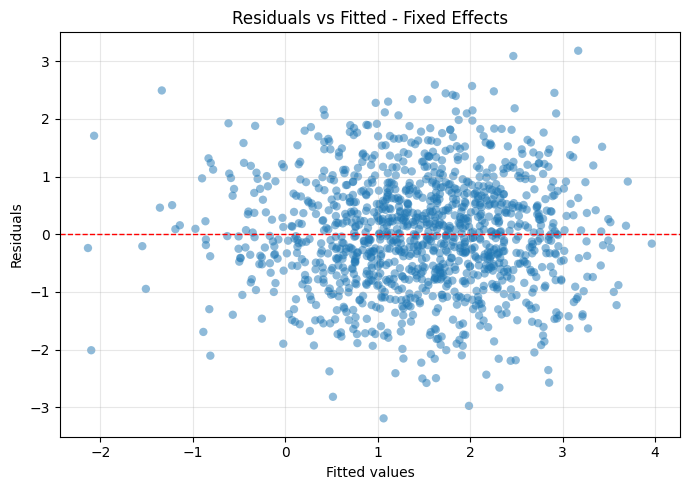

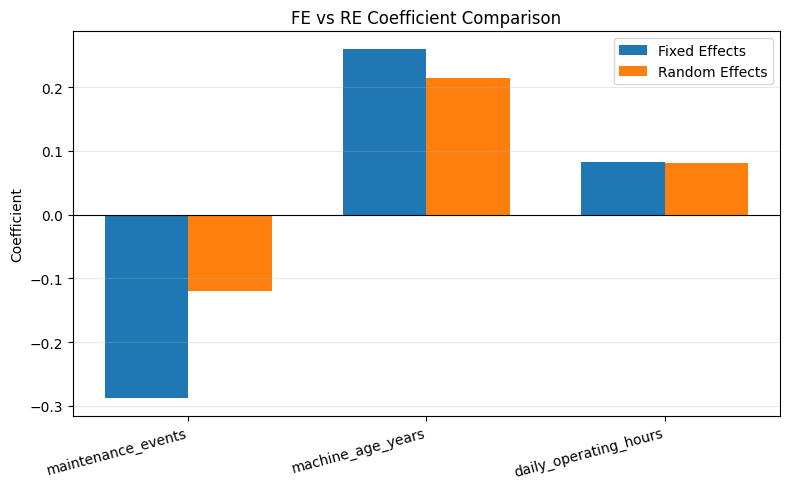

In [6]:
# 殘差診斷圖（以固定效果模型為例）
analyzer.plot_residuals_vs_fitted(fe)

# FE vs RE 係數比較圖
analyzer.plot_coefficient_comparison(fe, re)